In [1]:
import numpy as np
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

Text(0, 0.5, 'Y')

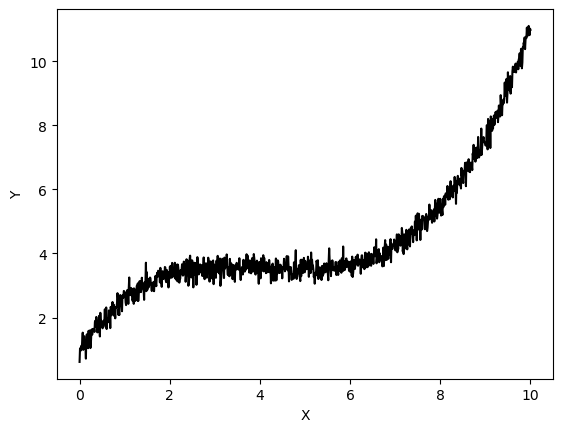

In [2]:

A = 1 # np.random.normal(loc=1, scale=0.5, size=1).round(2), 1
B = 2 # np.random.normal(loc=2, scale=0.5, size=1).round(2)
C = -0.5 # np.random.normal(loc=-0.5, scale=0.5, size=1).round(2)
D = 0.04 # np.random.normal(loc=0.04, scale=0.05, size=1).round(2)
x_true = np.linspace(0, 10, 1000)
y_true = A + B * x_true + C * x_true**2 + D * x_true**3 + np.random.normal(loc=0, scale=0.2, size=1000)

plt.plot(x_true, y_true, color="black")
plt.xlabel('X')
plt.ylabel('Y')

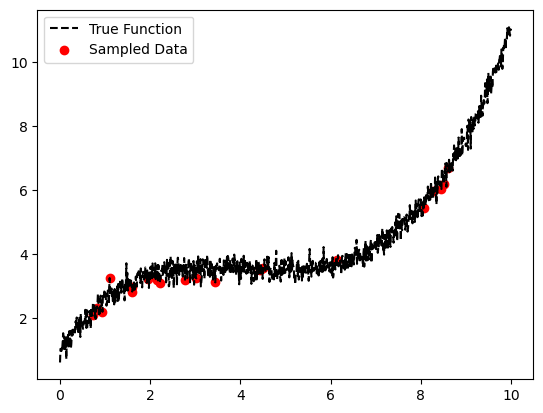

In [3]:
sample_size = 20
sampling_indices = np.random.choice(len(x_true), size=sample_size, replace=False)
x_sample = x_true[sampling_indices]
y_sample = y_true[sampling_indices] 

plt.plot(x_true, y_true, color="black", label="True Function", linestyle='--')
plt.scatter(x_sample, y_sample, color="red", label="Sampled Data")
plt.legend()


In [14]:
def define_model(num_neurons, num_depth):
    layers = []
    input_size = 1
    for _ in range(num_depth):
        layers.append(nn.Linear(input_size, num_neurons))
        layers.append(nn.ReLU())
        input_size = num_neurons
    layers.append(nn.Linear(input_size, 1))
    model = nn.Sequential(*layers)
    return model
def preprocess_data(x):
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
    # standardize the data
    x_mean = x_tensor.mean()
    x_std = x_tensor.std()
    x_tensor = (x_tensor - x_mean) / x_std
    return x_tensor, x_mean.detach().numpy(), x_std.detach().numpy()

def train_model(model, x_train, y_train, num_epochs=1000, learning_rate=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(x_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    
    return model
def evaluate_model(model, x_eval):
    x_preprocessed, x_mean, x_std = preprocess_data(x_eval)
    y_pred = model(x_preprocessed).detach().numpy().flatten()
    return y_pred 



In [15]:
def train_multiple_times(model, x_train, y_train, x_test, n_runs=15):
    # preprocess the training data
    x_train_tensor, x_sample_mean, x_sample_std = preprocess_data(x_train)
    y_train_tensor, y_sample_mean, y_sample_std = preprocess_data(y_train)
    all_predictions = []
    for run in range(n_runs):
        # Re-initialize the model weights
        model.apply(lambda m: m.reset_parameters() if hasattr(m, 'reset_parameters') else None)
        # Train the model
        trained_model = train_model(model, x_train_tensor, y_train_tensor)
        # Get predictions
        predictions = evaluate_model(trained_model, x_test)
        all_predictions.append(predictions * y_sample_std + y_sample_mean)
    return np.array(all_predictions)
    

In [11]:

x_test_1 = np.linspace(-20, 20, 100)
y_test_1 = (A + B * x_test_1 + C * x_test_1**2 + D * x_test_1**3).round(2)




In [12]:
model_complex = define_model(num_neurons=64, num_depth=1)

In [16]:
all_predictions = train_multiple_times(model_complex, x_sample, y_sample, x_test_1, n_runs=15)


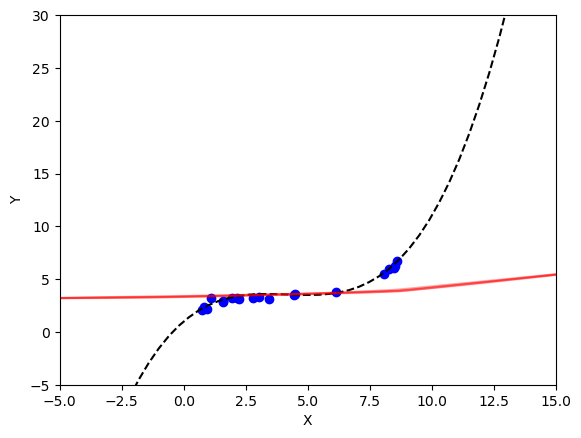

In [17]:
# Plot all predictions to show the variability due to different random initializations
plt.plot(x_test_1, y_test_1, color="black", label="True Function", linestyle='--')
for i in range(all_predictions.shape[0]):
    plt.plot(x_test_1, all_predictions[i], color="red", alpha=0.1)
plt.xlabel('X')
plt.ylabel('Y')
plt.ylim(-5, 30)
plt.xlim(-5, 15)
plt.scatter(x_sample, y_sample, color="blue", label="Sampled Data")

In [ ]:
# Fit neural network with many parameters to noisy data
def train_nn_with_noisy_data_many_times(x_sample, y_sample, noise_std, x_test, num_neurons, n_runs=50):
    all_predictions = []
    x_noisy_sample = x_sample + np.random.normal(0, noise_std, size=x_sample.shape)
    y_noisy_sample = y_sample + np.random.normal(0, noise_std, size=y_sample.shape)
    x_sample_mean, x_sample_std = np.mean(x_noisy_sample), np.std(x_noisy_sample)
    y_sample_mean, y_sample_std = np.mean(y_noisy_sample), np.std(y_noisy_sample)
    for run in range(n_runs):
        x_sample_noisy_standardized = (x_noisy_sample - x_sample_mean) / x_sample_std
        y_sample_noisy_standardized = (y_noisy_sample - y_sample_mean) / y_sample_std
        # Create a new model instance with the specified number of neurons
        model = nn.Sequential(
            nn.Linear(1, num_neurons),
            nn.ReLU(),
            nn.Linear(num_neurons, 1)
        )
        criterion = nn.MSELoss()
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
        
        # Train the model on the noisy data
        x_train = torch.from_numpy(x_sample_noisy_standardized.reshape(-1, 1)).float()
        y_train = torch.from_numpy(y_sample_noisy_standardized.reshape(-1, 1)).float()
        train_model(model, criterion, optimizer, x_train, y_train, epochs=5000)
        
        # Get predictions on the test set
        predictions = predict(model, x_test, x_sample_mean, x_sample_std, y_sample_mean, y_sample_std)
        all_predictions.append(predictions)
    return np.array(all_predictions)

In [ ]:
num_neurons = 1000
all_nn_predictions_noisy = train_nn_with_noisy_data_many_times(
    x_sample, y_sample, noise_std, x_test, num_neurons=num_neurons, n_runs=50)

plt.plot(x_test, y_test, color="black", label="True Function", linestyle='--')
for i in range(all_nn_predictions_noisy.shape[0]):
    plt.plot(x_test, all_nn_predictions_noisy[i], color="orange", alpha=0.1)
plt.scatter(x_sample, y_sample, color="red", label="Noisy Sampled Data")
plt.ylim(-5, 15)
plt.xlim(-5, 20)
plt.legend()

